In [ ]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency, f_oneway

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Data Prep**

In [ ]:
#load data into df
df = pd.read_csv('/content/drive/MyDrive/DAT 490 Capstone Project/heart_2020_cleaned.csv')

In [ ]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
#binary data
binary_cols = ['HeartDisease','Smoking','AlcoholDrinking','Stroke','DiffWalking',
               'PhysicalActivity','Asthma','KidneyDisease','SkinCancer']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [ ]:
#ordinal data
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54',
             '55-59','60-64','65-69','70-74','75-79','80 or older']
df['AgeCategory'] = df['AgeCategory'].map({v: i+1 for i, v in enumerate(age_order)})
df['GenHealth'] = df['GenHealth'].map({'Poor':1,'Fair':2,'Good':3,'Very good':4,'Excellent':5})
df['Diabetic'] = df['Diabetic'].map({'No':0,'Yes':1,'No, borderline diabetes':0,'Yes (during pregnancy)':1})

In [ ]:
#nominal
df = pd.get_dummies(df, columns=['Sex','Race'], drop_first=False)
dummy_cols = [c for c in df.columns if c.startswith('Sex_') or c.startswith('Race_')]
df[dummy_cols] = df[dummy_cols].astype(int)

 **Outlier Detection**

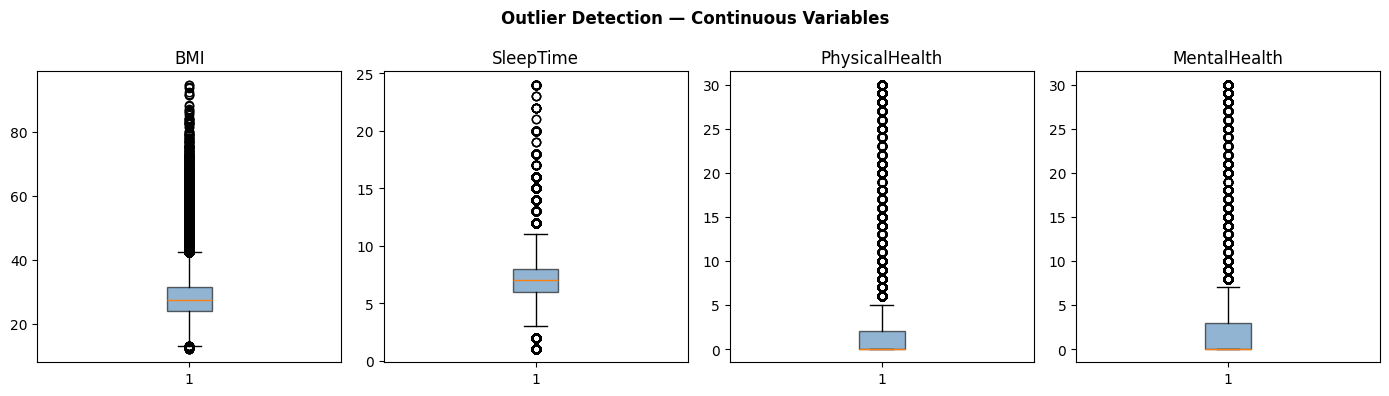

In [ ]:
continuous_cols = ['BMI','SleepTime','PhysicalHealth', 'MentalHealth']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, continuous_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Outlier Detection — Continuous Variables', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
for col in continuous_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: IQR bounds [{Q1-1.5*IQR:.1f}, {Q3+1.5*IQR:.1f}], outliers flagged = {n}")

BMI: IQR bounds [12.9, 42.5], outliers flagged = 10396
SleepTime: IQR bounds [3.0, 11.0], outliers flagged = 4543
PhysicalHealth: IQR bounds [-3.0, 5.0], outliers flagged = 47146
MentalHealth: IQR bounds [-4.5, 7.5], outliers flagged = 51576


**Correlation Heatmap**

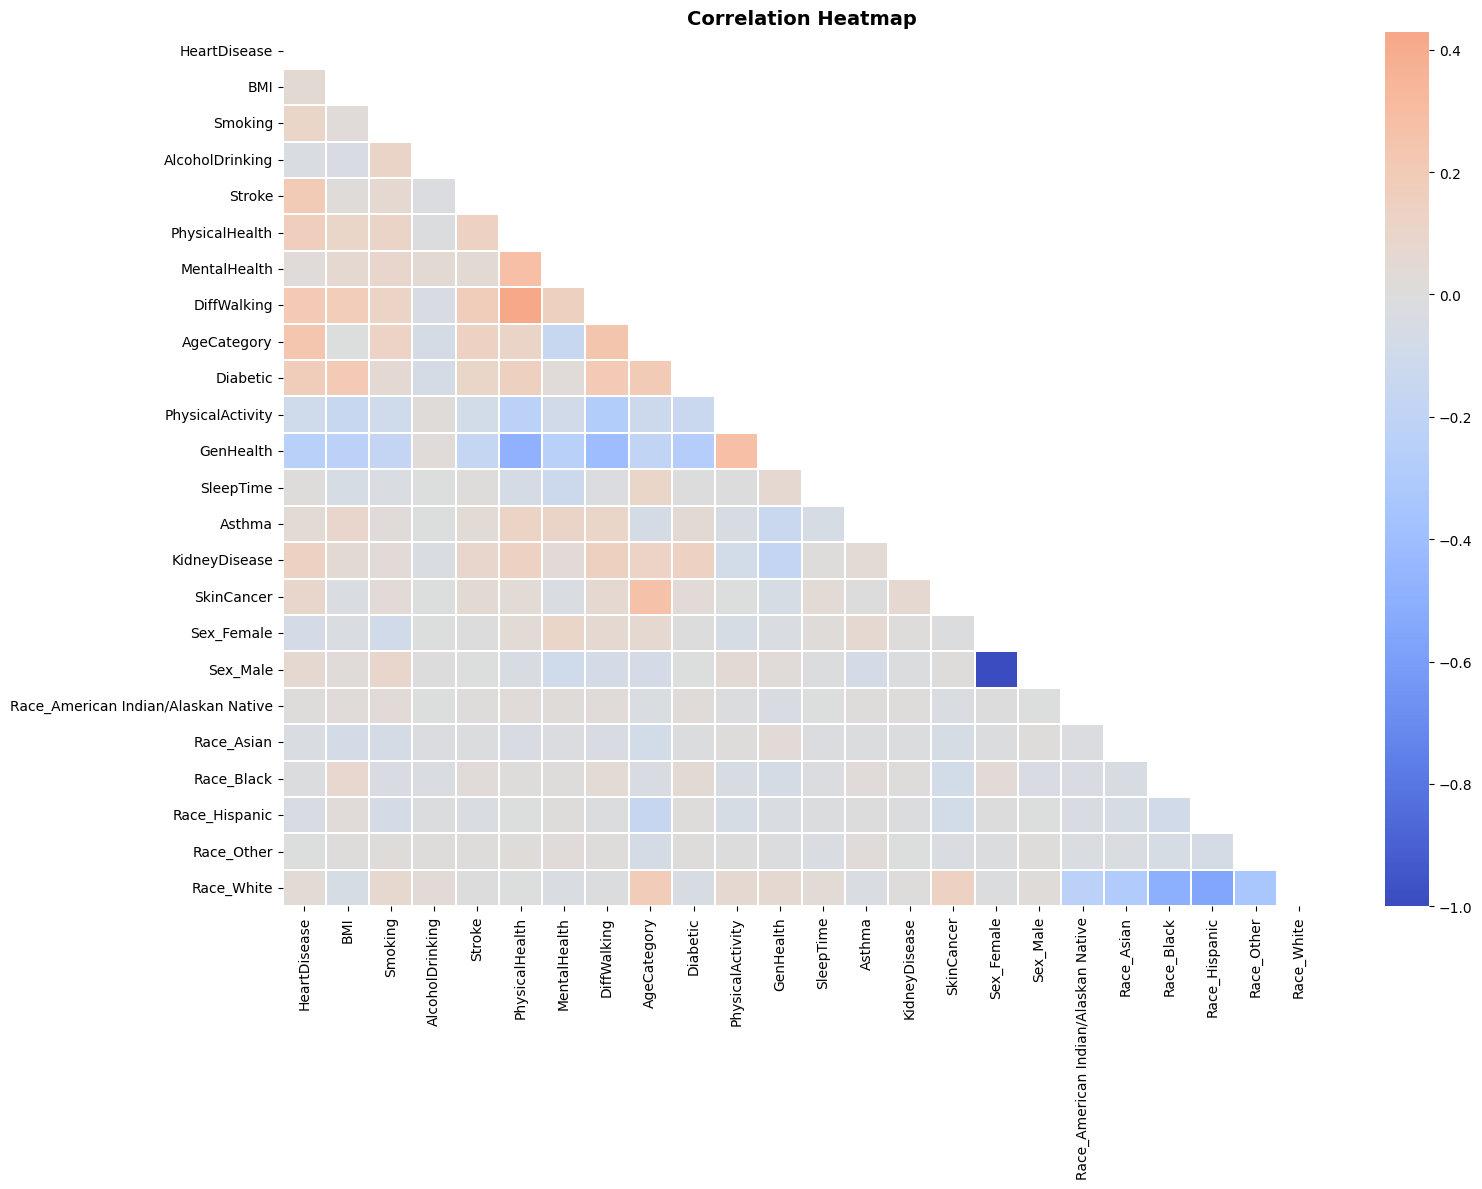

In [ ]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **RQ1: Which demographic, behavioral, and health-related factors are the strongest predictors of heart disease among U.S. adults?**

In [ ]:
X = df.drop(columns='HeartDisease')
y = df['HeartDisease']
feature_cols = X.columns.tolist()

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
}

**Results**

In [ ]:
cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=skf, scoring=['roc_auc','accuracy','f1'], n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: AUC={scores['test_roc_auc'].mean():.4f}, "
          f"Acc={scores['test_accuracy'].mean():.4f}, F1={scores['test_f1'].mean():.4f}")

#fit on full data
for name, model in models.items():
    model.fit(X, y)

Logistic Regression: AUC=0.8409, Acc=0.7511, F1=0.3492


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Random Forest: AUC=0.7880, Acc=0.9023, F1=0.1635
Decision Tree: AUC=0.8312, Acc=0.7284, F1=0.3338


**Cross Validation Comparison Chart**

/tmp/ipykernel_4325/874802183.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models.keys(), rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_4325/874802183.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models.keys(), rotation=15, ha='right', fontsize=8)
/tmp/ipykernel_4325/874802183.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models.keys(), rotation=15, ha='right', fontsize=8)


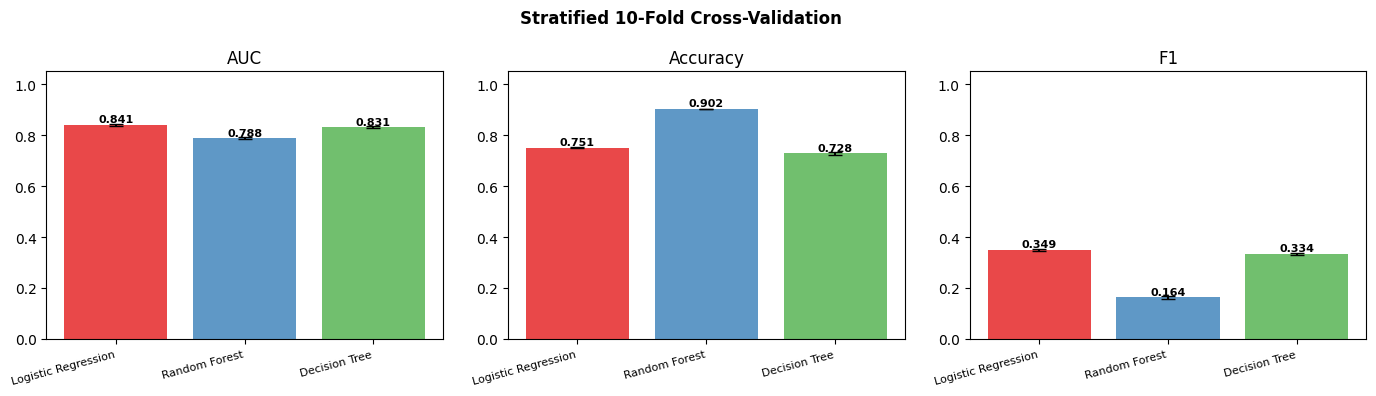

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric, label) in zip(axes, [('test_roc_auc','AUC'),('test_accuracy','Accuracy'),('test_f1','F1')]):
    means = [cv_results[m][metric].mean() for m in models]
    stds  = [cv_results[m][metric].std()  for m in models]
    bars = ax.bar(models.keys(), means, yerr=stds, capsize=5, color=['#e41a1c','#377eb8','#4daf4a'], alpha=0.8)
    ax.set_ylim(0, 1.05)
    ax.set_title(label)
    ax.set_xticklabels(models.keys(), rotation=15, ha='right', fontsize=8)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{v:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.suptitle('Stratified 10-Fold Cross-Validation', fontweight='bold')
plt.tight_layout()
plt.show()

**Confusion Matrices**

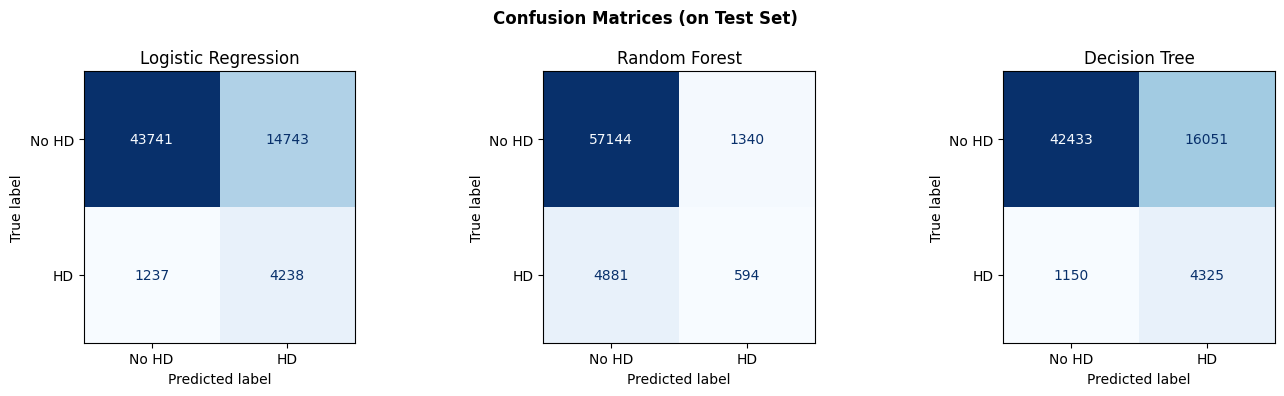

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, models.items()):
    #re-instantiate and fit model on training data for evaluation on test set
    m = type(model)(**model.get_params())
    m.fit(X_tr, y_tr)
    ConfusionMatrixDisplay(confusion_matrix(y_te, m.predict(X_te)), display_labels=['No HD','HD']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices (on Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

**ROC Curves**

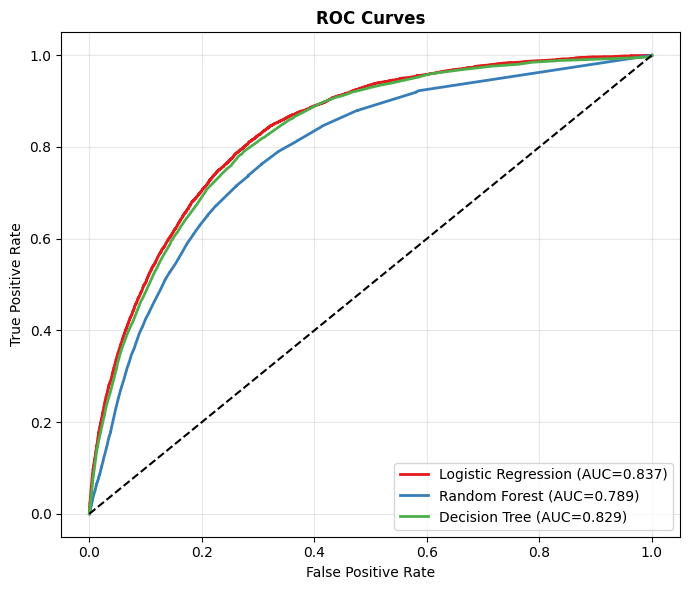

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
fig, ax = plt.subplots(figsize=(7, 6))
for (name, model), color in zip(models.items(), ['#e41a1c','#377eb8','#4daf4a']):
    m = type(model)(**model.get_params())
    m.fit(X_tr, y_tr)
    fpr, tpr, _ = roc_curve(y_te, m.predict_proba(X_te)[:,1])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves', fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Logistic Regression**

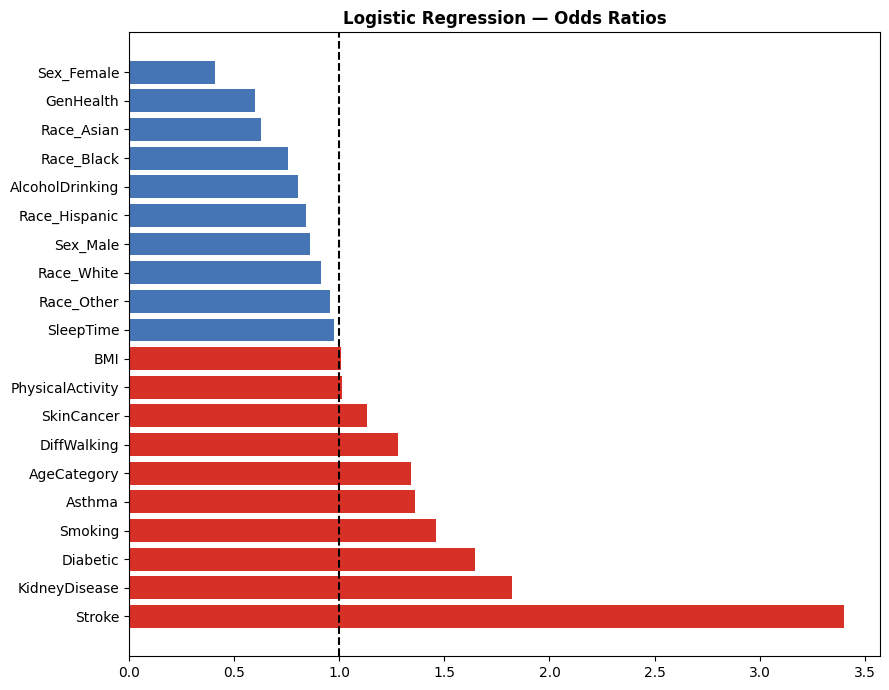

In [ ]:
lr = models['Logistic Regression']
odds_df = pd.DataFrame({'Feature': feature_cols, 'OddsRatio': np.exp(lr.coef_[0])}).sort_values('OddsRatio', ascending=False)
top_or = pd.concat([odds_df.head(10), odds_df.tail(10)])
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_or['Feature'], top_or['OddsRatio'],
        color=['#d73027' if v>1 else '#4575b4' for v in top_or['OddsRatio']])
ax.axvline(1, color='black', linestyle='--')
ax.set_title('Logistic Regression — Odds Ratios', fontweight='bold')
plt.tight_layout()
plt.show()

**Random Forest Feature Importance**

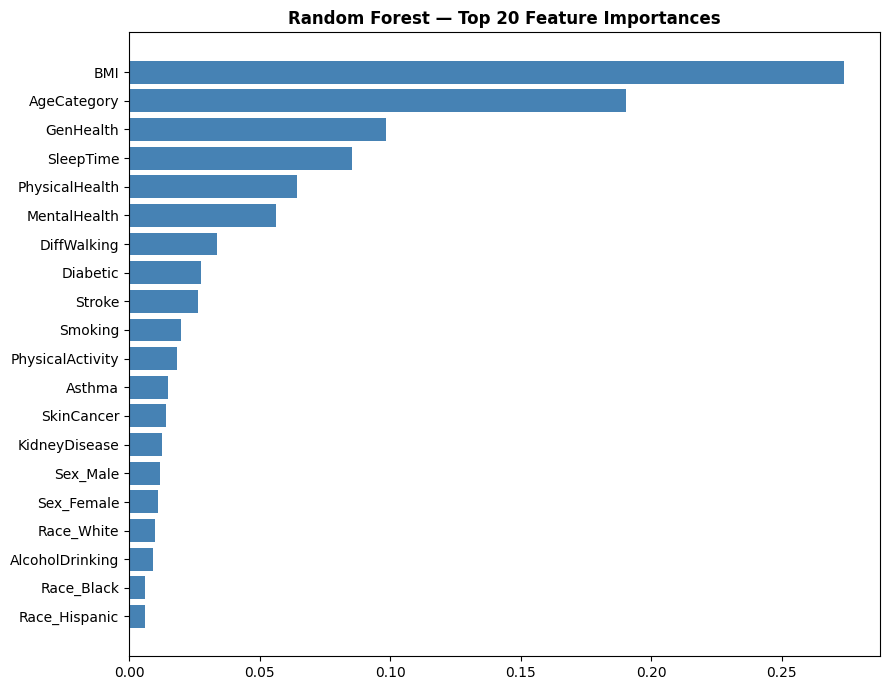

In [ ]:
rf = models['Random Forest']
fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1], color='steelblue')
ax.set_title('Random Forest — Top 20 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

**Decision Tree**

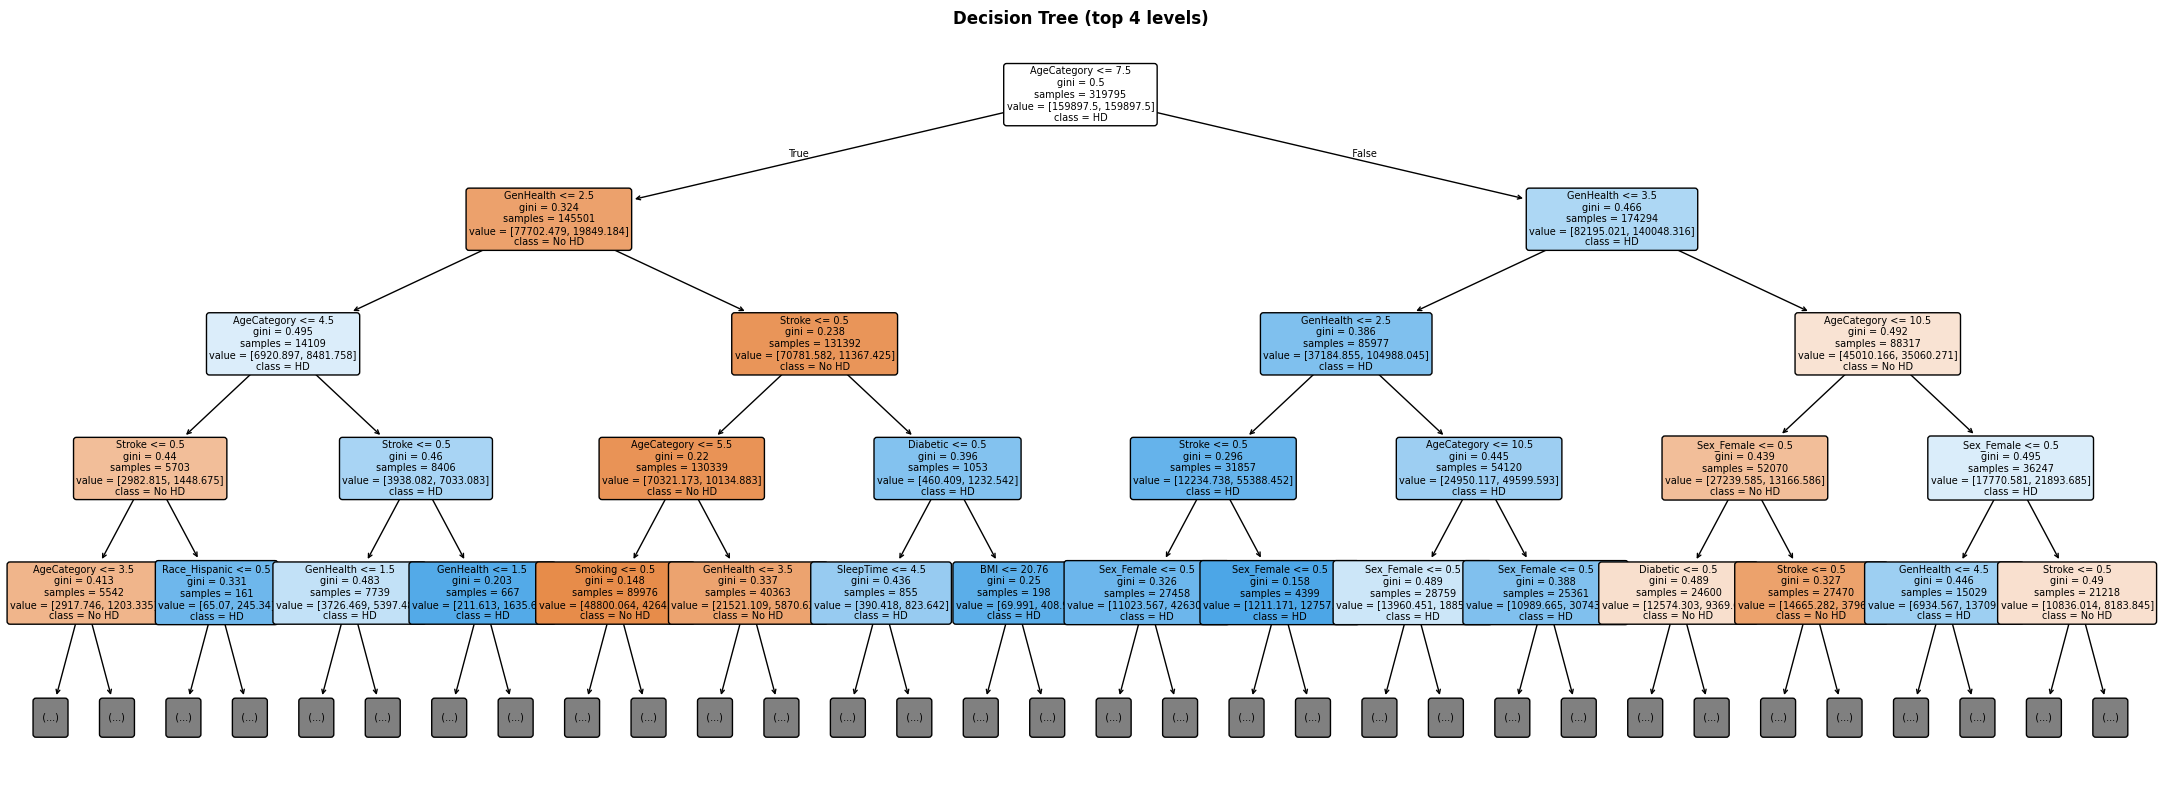

In [ ]:
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(models['Decision Tree'], feature_names=feature_cols, class_names=['No HD','HD'],
          max_depth=4, filled=True, rounded=True, fontsize=7, ax=ax)
plt.title('Decision Tree (top 4 levels)', fontweight='bold')
plt.tight_layout()
plt.show()

# **RQ2: What common characteristics define patient risk profiles and how do heart disease rates vary amongst these groupings?**

In [ ]:
X_cl = df.drop(columns='HeartDisease').fillna(df.drop(columns='HeartDisease').median()).copy()
X_cl[continuous_cols] = StandardScaler().fit_transform(X_cl[continuous_cols])

**Elbow Method**

In [ ]:
wcss = []
for k in range(1, 11):
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  wcss.append(km.fit(X_cl).inertia_)

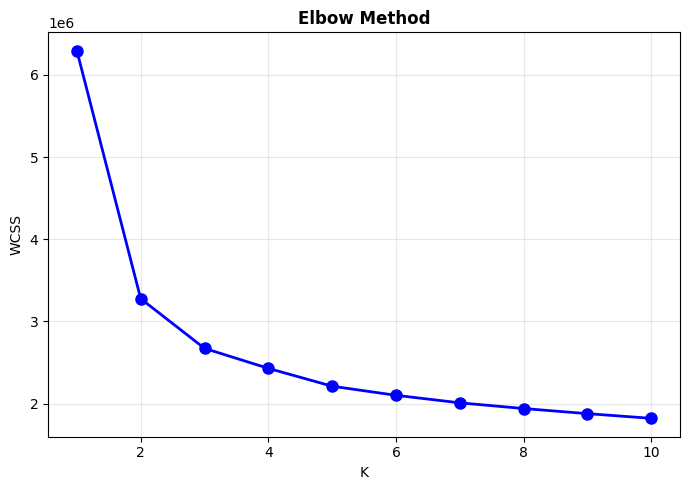

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(range(1,11), wcss, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('K'); ax.set_ylabel('WCSS')
ax.set_title('Elbow Method', fontweight='bold'); ax.grid(alpha=0.3)
plt.tight_layout()

In [ ]:
tss = ((X_cl - X_cl.mean())**2).sum().sum()
elbow_table = pd.DataFrame({'K': range(1, 11), 'WCSS': wcss})
elbow_table['R2'] = 1 - (elbow_table['WCSS'] / tss)
elbow_table['Additional R2'] = elbow_table['R2'].diff()
print(elbow_table.round(4))

    K          WCSS      R2  Additional R2
0   1  6.293753e+06 -0.0000            NaN
1   2  3.276278e+06  0.4794         0.4794
2   3  2.671335e+06  0.5756         0.0961
3   4  2.428112e+06  0.6142         0.0386
4   5  2.210760e+06  0.6487         0.0345
5   6  2.100175e+06  0.6663         0.0176
6   7  2.008540e+06  0.6809         0.0146
7   8  1.939335e+06  0.6919         0.0110
8   9  1.876893e+06  0.7018         0.0099
9  10  1.819850e+06  0.7108         0.0091


**Silhouette Analysis**

In [ ]:
sil = {}
for k in range(2, 9):
  labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_cl)
  sil[k] = silhouette_score(X_cl, labels, sample_size=5000, random_state=42)
  print(f"  K={k}: {sil[k]:.4f}")

best_k = max(sil, key=sil.get)
print(f">> Best K = {best_k}")

  K=2: 0.3984
  K=3: 0.2608
  K=4: 0.2627
  K=5: 0.1952
  K=6: 0.1982
  K=7: 0.1563
  K=8: 0.1576
>> Best K = 2


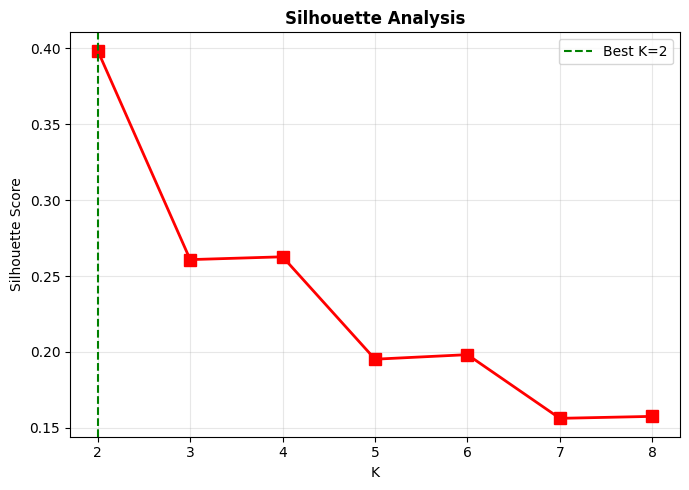

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(sil.keys()), list(sil.values()), 'rs-', linewidth=2, markersize=8)
ax.axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
ax.set_xlabel('K'); ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Analysis', fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()

**Final Clustering**

In [ ]:
df['Cluster'] = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_cl)

**Heart Disease Prevalence by Cluster**

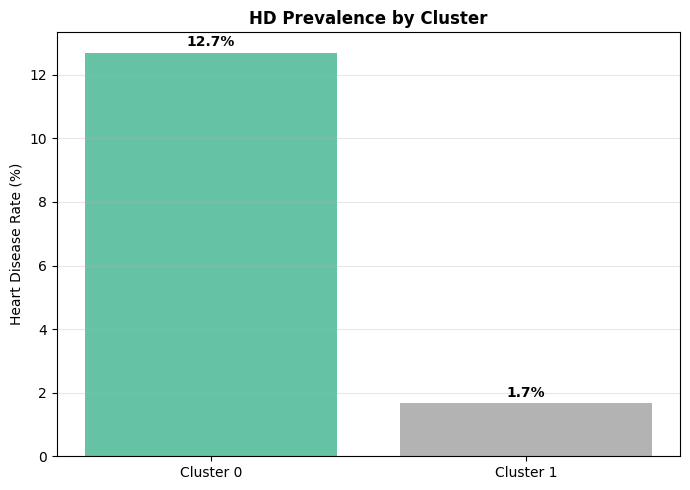

In [ ]:
hd_rate = df.groupby('Cluster')['HeartDisease'].mean() * 100
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([f'Cluster {i}' for i in hd_rate.index], hd_rate.values,
              color=plt.cm.Set2(np.linspace(0,1,best_k)))
ax.set_ylabel('Heart Disease Rate (%)'); ax.set_title('HD Prevalence by Cluster', fontweight='bold')
for bar, v in zip(bars, hd_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{v:.1f}%', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Cluster Heatmap**

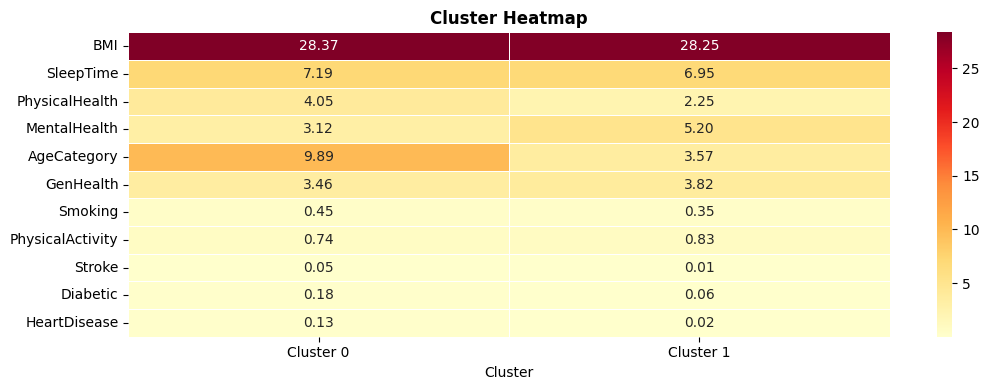

In [ ]:
key_vars = ['BMI','SleepTime','PhysicalHealth','MentalHealth','AgeCategory',
            'GenHealth','Smoking','PhysicalActivity','Stroke','Diabetic','HeartDisease']
cluster_summary = df.groupby('Cluster')[key_vars].mean().round(3)
fig, ax = plt.subplots(figsize=(11, max(4, best_k+2)))
sns.heatmap(cluster_summary[key_vars].T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Cluster {i}' for i in cluster_summary.index], linewidths=0.5, ax=ax)
ax.set_title('Cluster Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

**Chi-Square Tests**

In [ ]:
#cluster vs categorical features
for var in ['Smoking','Stroke','PhysicalActivity','Asthma','KidneyDisease','Diabetic','HeartDisease']:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df['Cluster'], df[var]))
    print(f"  {var}: chi2={chi2:.2f}, p={p:.4f}")

  Smoking: chi2=3084.40, p=0.0000
  Stroke: chi2=4090.13, p=0.0000
  PhysicalActivity: chi2=3077.92, p=0.0000
  Asthma: chi2=669.98, p=0.0000
  KidneyDisease: chi2=3250.25, p=0.0000
  Diabetic: chi2=10624.09, p=0.0000
  HeartDisease: chi2=11645.81, p=0.0000


**ANOVA**

In [ ]:
#ANOVA cluster vs continuous variables
for var in continuous_cols:
    groups = [df.loc[df['Cluster']==k, var].dropna().values for k in sorted(df['Cluster'].unique())]
    f, p = f_oneway(*groups)
    print(f"  {var}: F={f:.2f}, p={p:.4f}")

  BMI: F=23.46, p=0.0000
  SleepTime: F=2127.74, p=0.0000
  PhysicalHealth: F=3886.28, p=0.0000
  MentalHealth: F=5211.61, p=0.0000
